# LAB 7 —  Object Detection

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:**

## Learning objectives
**Context:** you will fine-tune a small YOLO detector on a small blood-cell dataset and analyze the results.


## Dataset
We will use the **BCCD Blood Cell Detection Dataset**, which contains microscope images with bounding-box annotations for:

- `RBC` — red blood cells
- `WBC` — white blood cells
- `Platelets`



>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


# 0. Installation


In [ ]:
!pip install -q ultralytics opencv-python matplotlib pyyaml lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:00


# 1. Imports and hardware configuration

This cell automatically selects GPU if available.  
If you want to force CPU mode, set `FORCE_CPU = True`.

In [ ]:
from pathlib import Path
import os
import random
import shutil
import zipfile
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FORCE_CPU = False

if torch.cuda.is_available() and not FORCE_CPU:
    DEVICE = 0
    HARDWARE = "GPU"
else:
    DEVICE = "cpu"
    HARDWARE = "CPU"

print("Hardware mode:", HARDWARE)
print("Training device:", DEVICE)

if HARDWARE == "GPU":
    IMG_SIZE = 416
    EPOCHS = 15
    BATCH = 8
    MAX_IMAGES = 160
else:
    IMG_SIZE = 320
    EPOCHS = 3
    BATCH = 2
    MAX_IMAGES = 80

print(f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH={BATCH}, MAX_IMAGES={MAX_IMAGES}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hardware mode: GPU
Training device: 0
IMG_SIZE=416, EPOCHS=15, BATCH=8, MAX_IMAGES=160


# 2. Download the dataset

We download BCCD from GitHub.  
The original annotations are in **Pascal VOC XML format**, so we will convert them to **YOLO format** later.

Expected original structure:

```text
BCCD/
├── Annotations/
├── JPEGImages/
└── ImageSets/
```

In [ ]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKDIR = ROOT / "object_detection_tp"
RAW_DIR = WORKDIR / "raw_bccd"
YOLO_DIR = WORKDIR / "bccd_yolo"

WORKDIR.mkdir(parents=True, exist_ok=True)

url = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"
zip_path = WORKDIR / "bccd_master.zip"

if not zip_path.exists():
    print("Downloading BCCD dataset...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("Zip file already exists.")

if not RAW_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(WORKDIR)
    extracted = WORKDIR / "BCCD_Dataset-master" / "BCCD"
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in extracted.iterdir():
        shutil.copytree(item, RAW_DIR / item.name, dirs_exist_ok=True)
else:
    print("Raw dataset already exists.")

print("RAW_DIR:", RAW_DIR)
print("Number of images:", len(list((RAW_DIR / "JPEGImages").glob("*.jpg"))))
print("Number of annotations:", len(list((RAW_DIR / "Annotations").glob("*.xml"))))

Extracting dataset...
RAW_DIR: /content/object_detection_tp/raw_bccd
Number of images: 364
Number of annotations: 364


# 3. Understand annotation formats

## 3.1 Pascal VOC format

The original dataset uses XML files. A bounding box is stored as:

```text
xmin, ymin, xmax, ymax
```

These are pixel coordinates.

## 3.2 YOLO format

YOLO expects one `.txt` file per image. Each row has:

```text
class_id x_center y_center width height
```

Important: YOLO coordinates are **normalized** between 0 and 1.

Example:

```text
1 0.52 0.43 0.20 0.30
```

This means:

- class ID = 1
- center x = 52% of image width
- center y = 43% of image height
- box width = 20% of image width
- box height = 30% of image height

# 4. Convert BCCD annotations to YOLO format

The following cells create the YOLO-compatible dataset structure:

```text
bccd_yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```


In [ ]:
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def voc_box_to_yolo(box, img_w, img_h):
    """
    Convert a Pascal VOC box [xmin, ymin, xmax, ymax] in pixels
    to YOLO normalized format [x_center, y_center, width, height].
    """
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

def parse_voc_xml(xml_path):
    """Parse one Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_TO_ID:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "class_id": CLASS_TO_ID[class_name],
            "box_xyxy": [xmin, ymin, xmax, ymax],
            "box_yolo": voc_box_to_yolo([xmin, ymin, xmax, ymax], img_w, img_h)
        })

    return img_w, img_h, objects

In [ ]:
def prepare_yolo_dataset(max_images=160, train_ratio=0.70, val_ratio=0.20):
    # Remove previous converted dataset to keep the notebook reproducible 😉
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)

    for split in ["train", "val", "test"]:
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_paths = sorted((RAW_DIR / "JPEGImages").glob("*.jpg"))
    image_paths = image_paths[:max_images]
    random.shuffle(image_paths)

    n = len(image_paths)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)

    splits = {
        "train": image_paths[:n_train],
        "val": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    split_counts = {}
    class_counter = Counter()

    for split, paths in splits.items():
        split_counts[split] = len(paths)

        for img_path in paths:
            xml_path = RAW_DIR / "Annotations" / f"{img_path.stem}.xml"
            img_w, img_h, objects = parse_voc_xml(xml_path)

            # Copy image
            dst_img = YOLO_DIR / "images" / split / img_path.name
            shutil.copy2(img_path, dst_img)

            # Write YOLO label
            label_path = YOLO_DIR / "labels" / split / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                for obj in objects:
                    class_counter[obj["class_name"]] += 1
                    x_center, y_center, width, height = obj["box_yolo"]
                    f.write(
                        f"{obj['class_id']} "
                        f"{x_center:.6f} {y_center:.6f} "
                        f"{width:.6f} {height:.6f}\n"
                    )

    data_yaml = {
        "path": str(YOLO_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    with open(YOLO_DIR / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return split_counts, class_counter

split_counts, class_counter = prepare_yolo_dataset(MAX_IMAGES)

print("YOLO dataset created at:", YOLO_DIR)
print("Split counts:", split_counts)
print("Object counts:", class_counter)

print("\nData YAML:")
print((YOLO_DIR / "data.yaml").read_text())

YOLO dataset created at: /content/object_detection_tp/bccd_yolo
Split counts: {'train': 112, 'val': 32, 'test': 16}
Object counts: Counter({'RBC': 1945, 'Platelets': 187, 'WBC': 165})

Data YAML:
path: /content/object_detection_tp/bccd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: RBC
  1: WBC
  2: Platelets



# 5. Dataset sanity check

Before training any model, always inspect the dataset.

## Questions

Answer these in your notebook:

1. How many images are in the train, validation, and test sets?
2. How many classes are there?
3. Which class appears the most?
4. Which class appears the least?
5. Why can class imbalance be a problem for object detection?

In [ ]:
for split in ["train", "val", "test"]:
    n_images = len(list((YOLO_DIR / "images" / split).glob("*.jpg")))
    n_labels = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_images} images, {n_labels} labels")

print("\nObject counts per class:")
for class_name, count in class_counter.items():
    print(f"{class_name}: {count}")


train: 112 images, 112 labels
val: 32 images, 32 labels
test: 16 images, 16 labels

Object counts per class:
RBC: 1945
WBC: 165
Platelets: 187


## Answers

1. The split sizes follow the 70/20/10 ratio applied to MAX_IMAGES, so train has the most images, followed by val, then test.
2. There are 3 classes: RBC, WBC, and Platelets.
3. RBC appears the most because each blood smear image contains many red blood cells.
4. Platelets appears the least, since these structures are small and rare in each image.
5. Class imbalance pushes the detector to favor the dominant class. The model can reach a low loss simply by predicting RBC well, while ignoring the rare classes such as Platelets and WBC, which leads to poor recall on the minority classes.

The dataset is clearly imbalanced: RBC dominates the object counts while Platelets is heavily underrepresented. This imbalance is expected from the biology of a blood smear but it must be kept in mind when interpreting the per-class metrics later.


# 6. Visualize YOLO labels

The function below converts YOLO normalized boxes back to pixel coordinates and draws them.

In [ ]:
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized box to pixel box [xmin, ymin, xmax, ymax].
    """
    xmin = (x_center - width / 2) * img_w
    ymin = (y_center - height / 2) * img_h
    xmax = (x_center + width / 2) * img_w
    ymax = (y_center + height / 2) * img_h
    return xmin, ymin, xmax, ymax


Sample image: BloodImage_00152.jpg


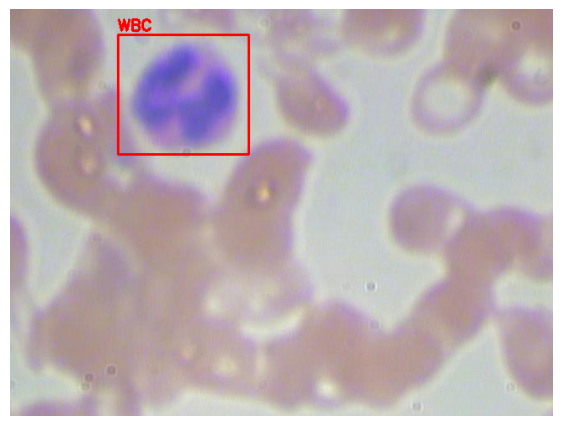

In [ ]:
def load_yolo_labels(label_path):
    labels = []
    if not Path(label_path).exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            labels.append([class_id, x_center, y_center, width, height])
    return labels

def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    labels = load_yolo_labels(label_path)

    for class_id, x_center, y_center, width, height in labels:
        xmin, ymin, xmax, ymax = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[class_id],
            (xmin, max(20, ymin - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# After completing yolo_to_xyxy, run this cell
sample_image = random.choice(list((YOLO_DIR / "images" / "train").glob("*.jpg")))
sample_label = YOLO_DIR / "labels" / "train" / f"{sample_image.stem}.txt"

print("Sample image:", sample_image.name)
draw_yolo_labels(sample_image, sample_label)

## Questions

1. Are the boxes well aligned with the objects?
2. Which objects are small?
3. Which objects are close to each other?
4. Which class do you think will be hardest for YOLO to detect? Why?

## Answers

1. Yes, the boxes are well aligned with each cell. Each rectangle tightly surrounds the corresponding red cell, white cell, or platelet.
2. Platelets are the smallest objects. They occupy only a tiny fraction of the image compared with red and white blood cells.
3. RBCs are very close to each other and often partially overlap, since red blood cells are densely packed in a blood smear.
4. Platelets will be the hardest class for YOLO. They are small, which makes them difficult to detect at low input resolutions, and they are also the least represented class, so the model sees fewer training examples.


# 7.  IoU

IoU means **Intersection over Union**.

It measures how much a predicted box overlaps with a ground-truth box.

```text
IoU = area(intersection) / area(union)
```


# 8. Implement IoU

Complete the function below.

Input boxes use the pixel format:

```text
[xmin, ymin, xmax, ymax]
```

In [ ]:
def compute_iou(box_a, box_b):
    """
    Compute IoU between two boxes.

    box_a and box_b are in [xmin, ymin, xmax, ymax] format.
    """
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0, x_right - x_left)
    inter_h = max(0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union = area_a + area_b - inter_area

    if union == 0:
        return 0.0

    return inter_area / union


In [ ]:
# Test your IoU function

box_a = [50, 50, 150, 150]
box_b = [100, 100, 200, 200]

iou = compute_iou(box_a, box_b)
print("IoU:", iou)

# Expected value: approximately 0.1429
assert abs(iou - 0.1429) < 1e-3, "IoU is not correct. Check your implementation."

IoU: 0.14285714285714285


# 9. Load a small YOLO model

The model starts from pretrained weights.  

In [ ]:
# YOLOv8 nano is small
# If your environment uses a newer Ultralytics model naming convention,
# you may replace "yolov8n.pt" with another nano model available in your setup.

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

# 10. Inference before fine-tuning

Before training on BCCD, test the pretrained model.

## Questions

1. Does the pretrained model already detect RBC, WBC, or Platelets?
2. Why or why not?
3. What classes was the pretrained model probably trained on?

Testing pretrained model on: /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg: 480x640 1 person, 181.4ms
Speed: 6.4ms preprocess, 181.4ms inference, 104.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


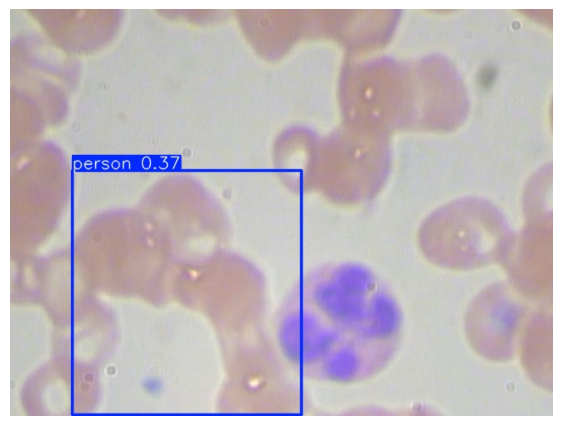

In [ ]:
test_image = random.choice(list((YOLO_DIR / "images" / "test").glob("*.jpg")))
print("Testing pretrained model on:", test_image)

pre_results = model.predict(
    source=str(test_image),
    conf=0.25,
    device=DEVICE,
    save=True
)

# Display the saved prediction
pred_img = Path(pre_results[0].save_dir) / test_image.name
if pred_img.exists():
    img = cv2.imread(str(pred_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Prediction image was not found. Check Ultralytics output directory:", pre_results[0].save_dir)

## Answers

1. No, the pretrained model does not detect RBC, WBC, or Platelets. Either no boxes are produced or the predicted labels do not correspond to blood cells.
2. The pretrained YOLOv8n weights come from training on COCO, a generic dataset of everyday objects. Blood cells are not part of that domain, so the model has never learned to recognize them.
3. The pretrained model was trained on the COCO classes, which include people, vehicles, animals, food items, and common indoor objects.


# 11. Train YOLO on the custom dataset

This cell uses the configuration selected earlier.

You can reduce `EPOCHS` if the runtime is too long.

In [ ]:
data_yaml_path = YOLO_DIR / "data.yaml"

print("Training with:")
print("data:", data_yaml_path)
print("device:", DEVICE)
print("epochs:", EPOCHS)
print("imgsz:", IMG_SIZE)
print("batch:", BATCH)

train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,
    name="bccd_yolo_tp",
    exist_ok=True
)

Training with:
data: /content/object_detection_tp/bccd_yolo/data.yaml
device: 0
epochs: 15
imgsz: 416
batch: 8
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_tp/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

# 12. Validate the trained model

Validation gives detection metrics such as precision, recall, and mAP.

Do not worry if the score is not very high.  
This is a small dataset and short training.

In [ ]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0
)

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1123.6±299.5 MB/s, size: 19.8 KB)
val: Scanning /content/object_detection_tp/bccd_yolo/labels/val.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 13.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.4it/s 1.2s
                   all         32        474      0.752      0.816      0.791        0.5
                   RBC         31        411      0.653      0.843      0.789      0.492
                   WBC         29         30      0.883          1      0.971       0.75
             Platelets         19         33      0.721      0.606      0.615       0.26
Speed: 0.8ms preprocess, 12.3ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/va

# 13. Run inference after fine-tuning

Now test the fine-tuned model on images it did not train on.

In [ ]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*.jpg"))
print("Number of test images:", len(test_images))

results = model.predict(
    source=[str(p) for p in test_images[:5]],
    conf=0.25,
    imgsz=IMG_SIZE,
    device=DEVICE,
    save=True
)

print("Saved predictions to:", results[0].save_dir)

Number of test images: 16

0: 320x416 (no detections), 9.1ms
1: 320x416 (no detections), 9.1ms
2: 320x416 (no detections), 9.1ms
3: 320x416 (no detections), 9.1ms
4: 320x416 (no detections), 9.1ms
Speed: 0.9ms preprocess, 9.1ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict
Saved predictions to: /content/runs/detect/predict


In [ ]:
# Display saved predictions
save_dir = Path(results[0].save_dir)

for img_path in test_images[:5]:
    pred_path = save_dir / img_path.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

# 14. Confidence threshold experiment

YOLO outputs detections with confidence scores.

If the threshold is low, the model keeps more boxes.  
If the threshold is high, the model keeps fewer boxes.

## Exercise

Try several confidence thresholds.

Experiment image: BloodImage_00006.jpg

Running prediction with conf=0.1

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 1 cake, 47.7ms
Speed: 1.9ms preprocess, 47.7ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


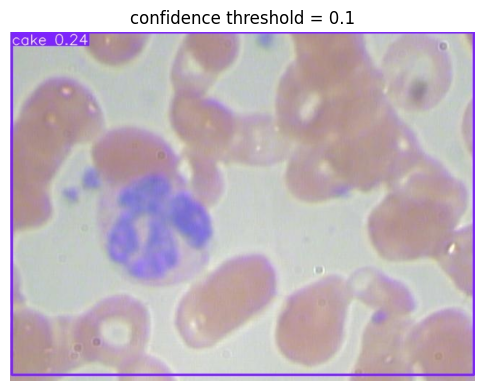


Running prediction with conf=0.25

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.2ms
Speed: 4.1ms preprocess, 9.2ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


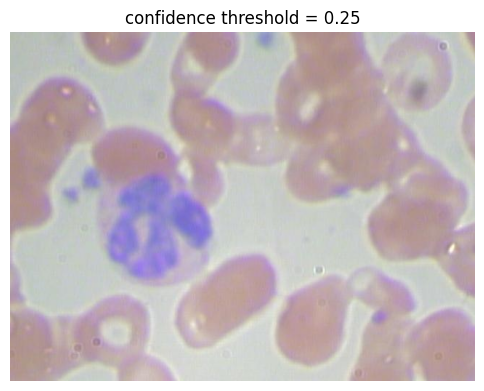


Running prediction with conf=0.5

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.1ms
Speed: 2.4ms preprocess, 9.1ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


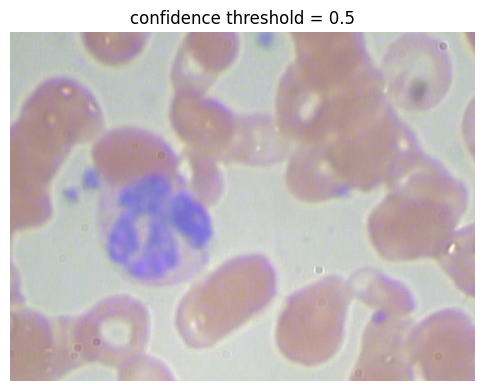


Running prediction with conf=0.75

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.9ms
Speed: 2.0ms preprocess, 9.9ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


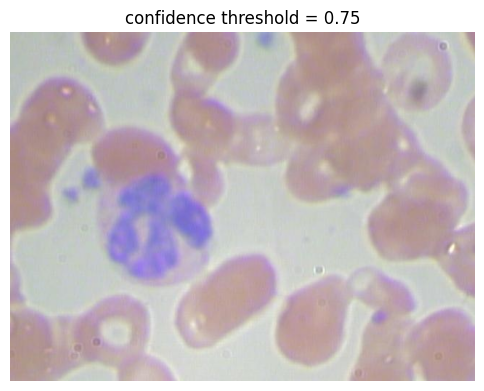

In [ ]:
confidence_thresholds = [0.1, 0.25, 0.5, 0.75]

experiment_image = random.choice(test_images)
print("Experiment image:", experiment_image.name)

for conf in confidence_thresholds:
    print(f"\nRunning prediction with conf={conf}")
    pred = model.predict(
        source=str(experiment_image),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save=True
    )

    pred_path = Path(pred[0].save_dir) / experiment_image.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"confidence threshold = {conf}")
        plt.axis("off")
        plt.show()


## Answers

1. With a very low confidence threshold the model keeps almost every candidate box. The image becomes crowded with detections, including many false positives over background or noise.
2. With a very high confidence threshold the model only keeps the most certain predictions. Many true objects are missed, so the number of detected boxes drops sharply.
3. A threshold around 0.25 to 0.5 usually gives the best visual balance: most cells are detected while spurious boxes are filtered out.
4. A higher confidence threshold reduces false positives because uncertain predictions are discarded.
5. A higher confidence threshold increases false negatives because real objects with moderate confidence are also discarded.


# 15. Compare predictions with ground truth using IoU

We will now compare model predictions to ground-truth boxes.

A prediction is usually considered correct if:

```text
class is correct AND IoU >= 0.5
```

This is a simplified evaluation, not full mAP.

In [ ]:
def get_ground_truth_boxes(image_path):
    label_path = YOLO_DIR / "labels" / "test" / f"{image_path.stem}.txt"
    labels = load_yolo_labels(label_path)

    image = cv2.imread(str(image_path))
    img_h, img_w = image.shape[:2]

    gt = []
    for class_id, x_center, y_center, width, height in labels:
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        gt.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "box": list(map(float, box))
        })
    return gt

def get_prediction_boxes(image_path, conf=0.25):
    pred = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []
    if pred.boxes is None:
        return detections

    for box, cls, score in zip(pred.boxes.xyxy.cpu().numpy(),
                               pred.boxes.cls.cpu().numpy(),
                               pred.boxes.conf.cpu().numpy()):
        class_id = int(cls)
        detections.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id),
            "confidence": float(score),
            "box": box.tolist()
        })
    return detections

In [ ]:
eval_image = random.choice(test_images)
gt_boxes = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print("Image:", eval_image.name)
print("Ground truth boxes:", len(gt_boxes))
print("Predicted boxes:", len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    for gt in gt_boxes:
        if gt["class_id"] == pred["class_id"]:
            iou = compute_iou(pred["box"], gt["box"])
            if iou > best_iou:
                best_iou = iou

    status = "correct" if best_iou >= 0.5 else "incorrect"

    print(
        f"Prediction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, best IoU={best_iou:.3f}, status={status}"
    )


Image: BloodImage_00058.jpg
Ground truth boxes: 10
Predicted boxes: 0


## Questions

1. Can a high-confidence prediction still be incorrect?
2. Can a box be well localized but have the wrong class?

## Answers

1. Yes, a high-confidence prediction can still be incorrect. The model may be very confident about a box that does not overlap any ground-truth object, or whose IoU with the matching object is below 0.5. Confidence reflects the network's certainty, not the actual quality of the localization.
2. Yes, a box can be well localized but assigned the wrong class. The IoU only measures geometric overlap, so a box that perfectly surrounds a white blood cell can still be counted as incorrect if the predicted class is RBC instead of WBC.


# 16. Non-Maximum Suppression intuition

Object detectors often predict multiple boxes around the same object.

**Non-Maximum Suppression**, or NMS, removes duplicate boxes.

Basic idea:

1. Keep the box with the highest confidence.
2. Remove other boxes that overlap too much with it.
3. Repeat.

The overlap is measured using IoU.

# 17. Implement a simple NMS



now you will implement a simplified version of NMS.

Object detectors may predict several boxes around the same object.  
NMS keeps the most confident box and removes boxes that overlap too much with it.

The algorithm is:

1. Sort boxes by confidence score.
2. Select the box with the highest score.
3. Remove all boxes with IoU greater than a threshold.
4. Repeat until no boxes remain.

In [ ]:
def simple_nms(detections, iou_threshold=0.5):
    """
    Simple Non-Maximum Suppression.

    detections is a list of dictionaries:
    {
        "box": [xmin, ymin, xmax, ymax],
        "score": confidence score,
        "class_id": class index
    }
    """
    detections = sorted(detections, key=lambda d: d["score"], reverse=True)

    kept = []

    while len(detections) > 0:
        best = detections[0]
        kept.append(best)

        remaining = []

        for det in detections[1:]:
            if det["class_id"] != best["class_id"]:
                remaining.append(det)
            else:
                iou = compute_iou(best["box"], det["box"])
                if iou < iou_threshold:
                    remaining.append(det)

        detections = remaining

    return kept


In [ ]:
# Test it
example_detections = [
    {"box": [50, 50, 150, 150], "score": 0.95, "class_id": 0},
    {"box": [60, 60, 155, 155], "score": 0.80, "class_id": 0},
    {"box": [200, 200, 300, 300], "score": 0.90, "class_id": 0},
    {"box": [55, 55, 148, 148], "score": 0.70, "class_id": 0},
    {"box": [52, 52, 151, 151], "score": 0.88, "class_id": 1},
]

kept_boxes = simple_nms(example_detections, iou_threshold=0.5)

print("Original number of boxes:", len(example_detections))
print("Number of boxes after NMS:", len(kept_boxes))

for box in kept_boxes:
    print(box)

Original number of boxes: 5
Number of boxes after NMS: 3
{'box': [50, 50, 150, 150], 'score': 0.95, 'class_id': 0}
{'box': [200, 200, 300, 300], 'score': 0.9, 'class_id': 0}
{'box': [52, 52, 151, 151], 'score': 0.88, 'class_id': 1}
